In [ ]:
import os
api_key = os.getenv("FRED_API_KEY", "")


In [209]:
import requests
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline
import pandas as pd
from sklearn.decomposition import PCA
import itertools

In [211]:
def fetch_fred_rates(series_id, api_key, start_date, end_date):
    # date should be in yyyy-mm-dd format
    url = "https://api.stlouisfed.org/fred/series/observations"
    params = {
        "series_id": series_id,
        "api_key": api_key,
        "file_type": "json",
        "observation_start": start_date,
        "observation_end": end_date
    }

    response = requests.get(url, params)
    df = pd.DataFrame.from_dict(response.json()['observations'])
    df.drop(columns = ['realtime_start', 'realtime_end'], inplace = True)
    df.dropna(axis = 0, inplace = True)
    df = df[df['value'] != '.']
    df.set_index('date', inplace = True)
    df.index = pd.to_datetime(df.index)
    df['value'] = df['value'].astype(float)
    return df

In [213]:
def fetch_treasury_rates(series, api_key, start_date, end_date):
    # date should be in yyyy-mm-dd format
    rates = pd.DataFrame()
    for t, s_id in series:
        r = fetch_fred_rates(s_id, api_key, start_date, end_date)
        r.rename(columns = {"value": t}, inplace = True)
        rates = pd.concat([rates, r], axis = 1)
    rates.sort_index(inplace = True)
    rates.dropna(inplace = True)
    return rates

In [215]:
class RatesData:
    def __init__(self, rates_pct):
        self.rates_pct = rates_pct
        self.rates_pct.index = pd.to_datetime(rates_pct.index).normalize()
        self.rates_decimal = self.rates_pct/100
        
        self.dates = np.array(rates_pct.index)
        self.tenors = np.array(rates_pct.columns)
        self.latest_date = self.dates[-1]

        self.daily_changes_bp = self.rates_pct.diff().dropna()*100

    def get_curve(self, date, units = 'pct'):
        if date == None:
            date = self.latest_date

        if date not in self.dates:
            raise ValueError("Invalid Date")
            
        if units == "decimal":
            return self.rates_decimal.loc[date]
        elif units == "pct":
            return self.rates_pct.loc[date]
        else:
            raise ValueError("Invalid unit")

        

In [217]:
def fit_pca(daily_changes_bp, n_components = 3):
    # PCA
    # daily_changes_bp = rates_data.daily_changes_bp
    pca = PCA(n_components = n_components)
    pca.fit(daily_changes_bp)
    return pca

In [219]:
def fit_rolling_pca(daily_changes_bp, lookback = 252, n_components=3):
    
    dates = np.array(daily_changes_bp.index)
    rolling_pca = {}
    
    for idx in range(lookback, len(daily_changes_bp)+1):
        window = daily_changes_bp.iloc[idx-lookback:idx]
        pca_window = fit_pca(window)
        date = pd.Timestamp(dates[idx-1])        
        rolling_pca[date] = {
            "pca": pca_window,
            "start_date": dates[idx-lookback-1],
            "end_date": dates[idx-1],
            "components": pca_window.components_,
            "explained_variance_ratio": pca_window.explained_variance_ratio_,
            "mean": pca_window.mean_
        }
        
    return rolling_pca

In [221]:
def bump_curve(rates_data, date, maturity, bump = 0.0001):
    # Bumps at a particular node/maturity
    rate_curve = rates_data.get_curve(date, "decimal")
    rate_curve_up = rate_curve.copy()
    rate_curve_down = rate_curve.copy()
    rate_curve_up.loc[maturity] += bump
    rate_curve_down.loc[maturity] -= bump
    return rate_curve_up, rate_curve_down

def parallel_bump_curve(rates_data, date, bump = 0.0001):
    # Bumps parallelly across the curve
    rate_curve = rates_data.get_curve(date, "decimal")
    rate_curve_up = rate_curve.copy()
    rate_curve_down = rate_curve.copy()
    rate_curve_up += bump
    rate_curve_down -= bump
    return rate_curve_up, rate_curve_down

In [223]:
def bond_pricer(face_value, c, T, rate_curve, cs, f):
    # rates curve must be in decimals
    pv = 0
    n = int(round(f*T))
    for i in range(n):
        t = float((i + 1)/f)
        if t in rate_curve.index:
            r = rate_curve[t]
        else:
            r = float(cs(t))
        
        cf = (c/f)*face_value
        if i == n - 1:
            cf += face_value
        dcf = cf/pow(1+r/f, i + 1)
        pv += dcf
    return pv

In [225]:
def make_delta_ladder(portfolio, rates_data, date):
    maturities = rates_data.tenors
    
    delta_ladder = []
    
    for maturity in maturities:
        # Bumping rates for the chosen maturity
        rates_up, rates_down = bump_curve(rates_data, date, maturity)
        
        cs_up = CubicSpline(rates_up.index.astype(float).to_numpy(), rates_up.to_numpy(dtype = float))
        cs_down = CubicSpline(rates_down.index.astype(float).to_numpy(), rates_down.to_numpy(dtype = float))
        
        price_up = portfolio.apply(lambda row: bond_pricer(row["face_value"], row["coupon"],
                                                                        row["maturity"], rates_up, cs_up,
                                                                        row["frequency"]), axis = 1)
        
        price_down = portfolio.apply(lambda row: bond_pricer(row["face_value"], row["coupon"],
                                                                        row["maturity"], rates_down, cs_down,
                                                                        row["frequency"]), axis = 1)
    
        key_rate_dv01 = (price_down - price_up)/2
        signed_key_rate_dv01 = key_rate_dv01*portfolio["positions"]
        total_signed_key_rate_dv01 = signed_key_rate_dv01.sum()
        delta_ladder.append(total_signed_key_rate_dv01)

    return np.array(delta_ladder)

In [283]:
def pca_hedge(portfolio_ladder, hedge_ladders, pca):
    ladder_p1 = hedge_ladders[0]
    ladder_p2 = hedge_ladders[1]
    ladder_p3 = hedge_ladders[2]
    ladder_p4 = hedge_ladders[3]
    
    v1 = pca.components_[0]
    v2 = pca.components_[1]
    v3 = pca.components_[2]
    
    a1 = np.dot(v1, portfolio_ladder)
    b1 = np.dot(v1, ladder_p1)
    c1 = np.dot(v1, ladder_p2)
    d1 = np.dot(v1, ladder_p3)
    e1 = np.dot(v1, ladder_p4)
    
    a2 = np.dot(v2, portfolio_ladder)
    b2 = np.dot(v2, ladder_p1)
    c2 = np.dot(v2, ladder_p2)
    d2 = np.dot(v2, ladder_p3)
    e2 = np.dot(v2, ladder_p4)
    
    a3 = np.dot(v3, portfolio_ladder)
    b3 = np.dot(v3, ladder_p1)
    c3 = np.dot(v3, ladder_p2)
    d3 = np.dot(v3, ladder_p3)
    e3 = np.dot(v3, ladder_p4)
    
    A = np.array([[b1, c1, d1, e1], [b2, c2, d2, e2], [b3, c3, d3, e3]])
    y = np.array([-a1, -a2, -a3])
    
    # h1, h2, h3 = np.linalg.solve(A, y)

    # Use lstsq so the hedge construction works for square, overdetermined,
    # or underdetermined hedge systems. If exact factor neutralization is possible,
    # lstsq returns a solution; when multiple exact solutions exist, it returns the
    # minimum-norm hedge. If exact neutralization is not possible, it returns the
    # closest least-squares hedge.

    h, *_ = np.linalg.lstsq(A, y, rcond=None)

    return h

In [229]:
rates_pct = fetch_treasury_rates(series, api_key, start_date, end_date)
rates_data = RatesData(rates_pct)

In [230]:
t1 = pd.Timestamp('2026-01-02')
t2 = pd.Timestamp('2026-01-05')

In [231]:
daily_changes_bp = rates_data.daily_changes_bp
rolling_pca = fit_rolling_pca(daily_changes_bp)

In [232]:
rolling_pca[t1]

{'pca': PCA(n_components=3),
 'start_date': numpy.datetime64('2024-12-27T00:00:00.000000000'),
 'end_date': numpy.datetime64('2026-01-02T00:00:00.000000000'),
 'components': array([[ 0.03585763,  0.04482653,  0.10287081,  0.2367442 ,  0.36787961,
          0.38133725,  0.40582715,  0.40310129,  0.36188521,  0.31815916,
          0.29991432],
        [-0.03545921, -0.1271635 , -0.22563646, -0.36923343, -0.3930166 ,
         -0.30270153, -0.09070293,  0.06872433,  0.23200339,  0.46638855,
          0.51472592],
        [ 0.78614601,  0.44512524,  0.29628487,  0.11954992, -0.07830481,
         -0.15744438, -0.11814091, -0.09093125, -0.01790411,  0.10744678,
          0.12942008]]),
 'explained_variance_ratio': array([0.80587171, 0.10835589, 0.03047051]),
 'mean': array([-0.28571429, -0.26190476, -0.28174603, -0.28968254, -0.33333333,
        -0.32142857, -0.28174603, -0.23015873, -0.17063492, -0.03174603,
         0.01587302])}

In [335]:
hedge_instruments = pd.DataFrame({
    "bond": ["2Y Hedge Note", "5Y Hedge Note", "10Y Hedge Note", "30Y Hedge Bond"],
    "face_value": [1_000_000, 1_000_000, 1_000_000, 1_000_000],
    "coupon": [0.04, 0.04, 0.04, 0.04],
    "maturity": [2, 5, 10, 30],
    "frequency": [2, 2, 2, 2],
    "positions": [1, 1, 1, 1]
})
portfolio = pd.DataFrame({
    "bond": ["2Y Note", "5Y Note", "10Y Note", "30Y Bond"],
    "face_value": [5_000_000, 4_000_000, 3_000_000, 2_000_000],
    "coupon": [0.040, 0.042, 0.045, 0.047],
    "maturity": [2, 5, 10, 30],
    "frequency": [2, 2, 2, 2],
    "positions": [1, 1, 1, 1]
})

In [234]:
portfolio_ladder = make_delta_ladder(portfolio, rates_data, t1)
p1_ladder = make_delta_ladder(p1, rates_data, t1)
p2_ladder = make_delta_ladder(p2, rates_data, t1)
p3_ladder = make_delta_ladder(p3, rates_data, t1)

hedge_ladder = np.array([p1_ladder, p2_ladder, p3_ladder])

h1, h2, h3 = pca_hedge(portfolio_ladder, hedge_ladder, rolling_pca[t1]['pca'])

-7.527352967827003
-6.317158929095019
-1.3210642034589677


In [237]:
def portfolio_value(portfolio, rates_data, date):
    curve = rates_data.get_curve(date, units="decimal")

    cs = CubicSpline(
        curve.index.astype(float).to_numpy(),
        curve.to_numpy(dtype=float)
    )

    values = portfolio.apply(
        lambda row: row["positions"] * bond_pricer(
            row["face_value"],
            row["coupon"],
            row["maturity"],
            curve,
            cs,
            row["frequency"]
        ),
        axis=1
    )

    return values.sum()

In [238]:
hedge_portfolio = pd.concat([p1.copy(), p2.copy(), p3.copy()], ignore_index = True)
hedge_portfolio['positions'] = h
hedged_portfolio = pd.concat([
    portfolio,
    hedge_portfolio
], ignore_index=True)

In [255]:
portfolio_value(unhedged_portfolio, rates_data, t2) - portfolio_value(unhedged_portfolio, rates_data, t1)

16283.96055456996

In [257]:
portfolio_value(hedged_portfolio, rates_data, t2) - portfolio_value(hedged_portfolio, rates_data, t1)

790.0690623004921

In [259]:
dates = np.array(list(daily_changes_bp.index))

In [291]:
## PCA Hedge Stability Issue

# The initial hedge used 3 instruments to neutralize 3 PCA factors exactly. This occasionally produced unstable hedge weights because the hedge exposure matrix became ill-conditioned.

# To improve stability, I expanded the hedge universe to 2Y/5Y/10Y/30Y and solved with least squares. With more hedge instruments than factors, the solver selects a minimum-norm hedge when exact factor neutralization is possible.

In [285]:
unhedged_portfolio = portfolio
results = {}
lookback = 252
for date, next_date in zip(dates[lookback-1:-1], dates[lookback:]):
    date = pd.Timestamp(date)
    next_date = pd.Timestamp(next_date)
    
    portfolio_ladder = make_delta_ladder(portfolio, rates_data, date)
    p1_ladder = make_delta_ladder(p1, rates_data, date)
    p2_ladder = make_delta_ladder(p2, rates_data, date)
    p3_ladder = make_delta_ladder(p3, rates_data, date)
    p4_ladder = make_delta_ladder(p4, rates_data, date)
    
    hedge_ladder = np.array([p1_ladder, p2_ladder, p3_ladder, p4_ladder])
    
    h = pca_hedge(portfolio_ladder, hedge_ladder, rolling_pca[date]['pca'])

    hedge_portfolio = pd.concat([p1.copy(), p2.copy(), p3.copy(), p4.copy()], ignore_index = True)
    hedge_portfolio['positions'] = h
    hedged_portfolio = pd.concat([
        portfolio,
        hedge_portfolio
    ], ignore_index=True)
    
    unhedged_pnl = portfolio_value(unhedged_portfolio, rates_data, next_date) \
                    - portfolio_value(unhedged_portfolio, rates_data, date)

    hedged_pnl = portfolio_value(hedged_portfolio, rates_data, next_date) \
                - portfolio_value(hedged_portfolio, rates_data, date)

    pnl_reduction = abs(unhedged_pnl) - abs(hedged_pnl)
    
    results[date] = {'unhedged_pnl': unhedged_pnl, 'hedged_pnl': hedged_pnl,
                    'pnl_reduction': pnl_reduction, 'hedge_weights': h}



    
    

,value
num_days,2.536000e+03
avg_abs_unhedged_pnl,3.900127e+04
avg_abs_hedged_pnl,3.570777e+02
unhedged_pnl_vol,5.253277e+04
hedged_pnl_vol,5.881404e+02
worst_unhedged_pnl,-3.554031e+05
worst_hedged_pnl,-2.569404e+03
hit_rate,9.964511e-01
total_unhedged_pnl,-1.763017e+06
total_hedged_pnl,8.669908e+02


,unhedged_pnl,hedged_pnl,pnl_reduction,h_2y,h_5y,h_10y,h_30y,abs_unhedged_pnl,abs_hedged_pnl,hedge_helped,abs_pnl_reduction,cum_unhedged_pnl,cum_hedged_pnl
date,,,,,,,,,,,,,
2016-01-05,78432.581022,374.052708,78058.528313,-4.927867,-3.864023,-3.417115,-2.048298,78432.581022,374.052708,True,78058.528313,78432.581022,374.052708
2016-01-06,30323.040059,530.006014,29793.034045,-4.921276,-3.827356,-3.457824,-2.039506,30323.040059,530.006014,True,29793.034045,108755.621081,904.058723
2016-01-07,25297.344666,-230.867454,25066.477212,-4.920730,-3.959435,-3.316655,-2.073637,25297.344666,230.867454,True,25066.477212,134052.965747,673.191269
2016-01-08,-35189.667652,277.458435,34912.209217,-4.917731,-3.923059,-3.356167,-2.064033,35189.667652,277.458435,True,34912.209217,98863.298095,950.649703
2016-01-11,57325.293474,596.841290,56728.452184,-4.883271,-3.595447,-3.724169,-1.974251,57325.293474,596.841290,True,56728.452184,156188.591569,1547.490994


The hedge reduced average absolute daily P&L by 99.08%.
The hedge reduced daily P&L volatility by 98.88%.
The hedge reduced absolute P&L on 99.65% of days.


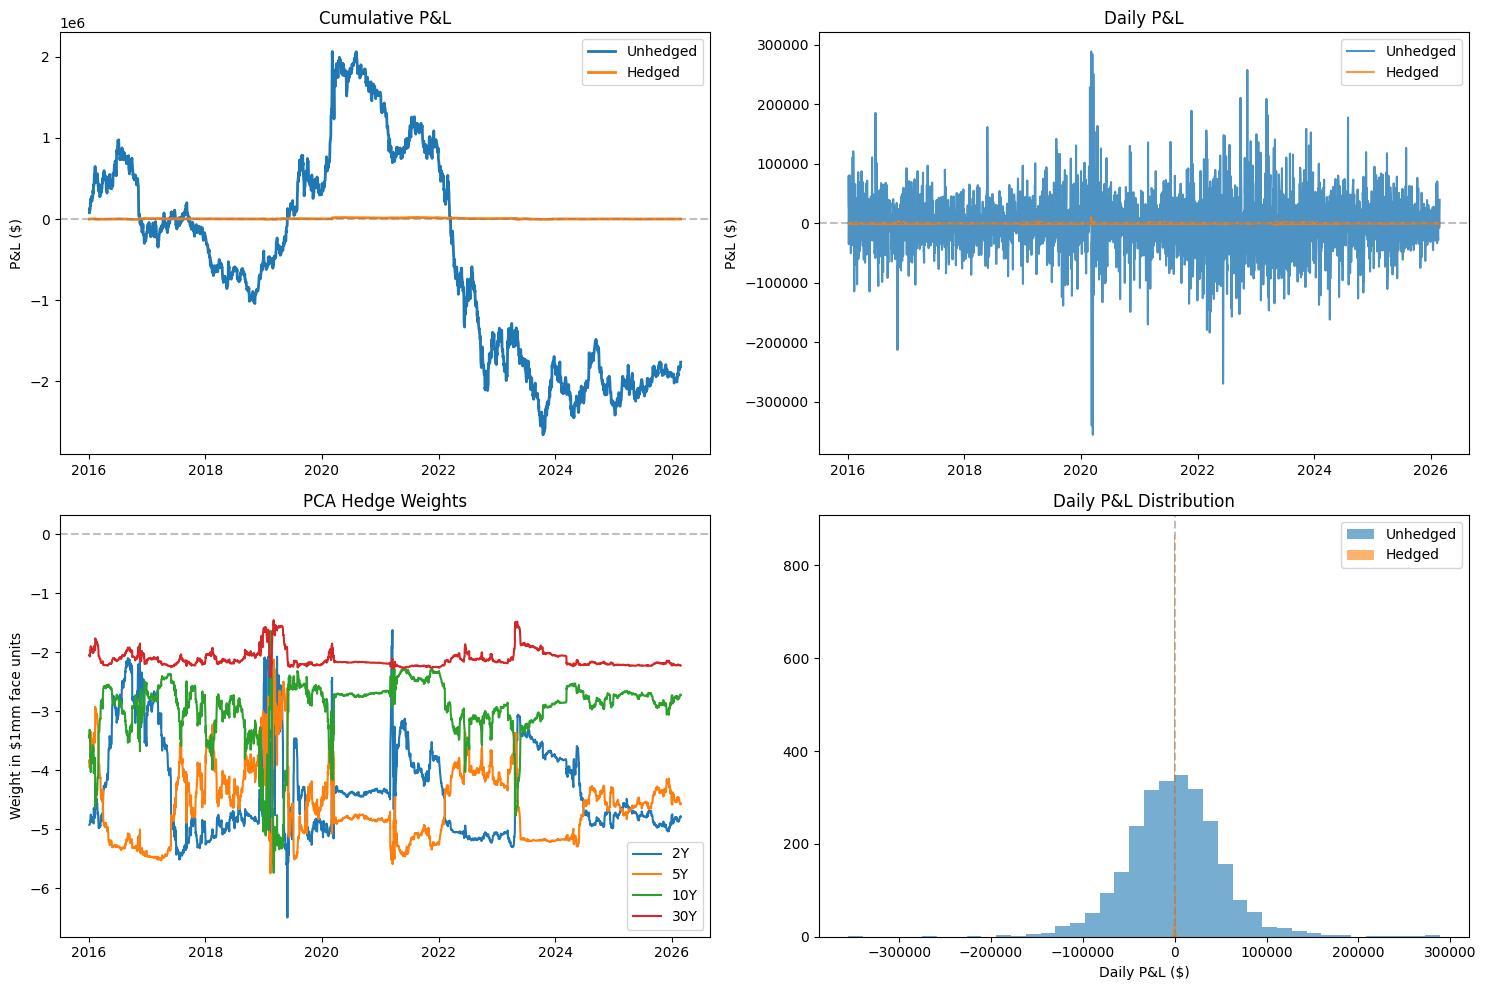

In [289]:
# =========================
# Multi-Day Hedge Backtest Reporting
# =========================

results_df = pd.DataFrame.from_dict(results, orient="index")
results_df.index = pd.to_datetime(results_df.index)
results_df = results_df.sort_index()
results_df.index.name = "date"

# Expand hedge weights
hedge_weights_df = pd.DataFrame(
    results_df["hedge_weights"].to_list(),
    index=results_df.index,
    columns=["h_2y", "h_5y", "h_10y", "h_30y"]
)

results_df = pd.concat(
    [results_df.drop(columns=["hedge_weights"]), hedge_weights_df],
    axis=1
)

# Metrics
results_df["abs_unhedged_pnl"] = results_df["unhedged_pnl"].abs()
results_df["abs_hedged_pnl"] = results_df["hedged_pnl"].abs()
results_df["hedge_helped"] = results_df["abs_hedged_pnl"] < results_df["abs_unhedged_pnl"]
results_df["abs_pnl_reduction"] = results_df["abs_unhedged_pnl"] - results_df["abs_hedged_pnl"]

results_df["cum_unhedged_pnl"] = results_df["unhedged_pnl"].cumsum()
results_df["cum_hedged_pnl"] = results_df["hedged_pnl"].cumsum()

summary = pd.Series({
    "num_days": len(results_df),
    "avg_abs_unhedged_pnl": results_df["abs_unhedged_pnl"].mean(),
    "avg_abs_hedged_pnl": results_df["abs_hedged_pnl"].mean(),
    "unhedged_pnl_vol": results_df["unhedged_pnl"].std(),
    "hedged_pnl_vol": results_df["hedged_pnl"].std(),
    "worst_unhedged_pnl": results_df["unhedged_pnl"].min(),
    "worst_hedged_pnl": results_df["hedged_pnl"].min(),
    "hit_rate": results_df["hedge_helped"].mean(),
    "total_unhedged_pnl": results_df["unhedged_pnl"].sum(),
    "total_hedged_pnl": results_df["hedged_pnl"].sum(),
})

summary["avg_abs_pnl_reduction_pct"] = (
    1 - summary["avg_abs_hedged_pnl"] / summary["avg_abs_unhedged_pnl"]
)

summary["pnl_vol_reduction_pct"] = (
    1 - summary["hedged_pnl_vol"] / summary["unhedged_pnl_vol"]
)

display(summary.to_frame("value"))
display(results_df.head())

print(
    f"The hedge reduced average absolute daily P&L by "
    f"{summary['avg_abs_pnl_reduction_pct']:.2%}."
)
print(
    f"The hedge reduced daily P&L volatility by "
    f"{summary['pnl_vol_reduction_pct']:.2%}."
)
print(
    f"The hedge reduced absolute P&L on "
    f"{summary['hit_rate']:.2%} of days."
)

# =========================
# Plots
# =========================

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# Cumulative P&L
ax[0, 0].plot(results_df.index, results_df["cum_unhedged_pnl"], label="Unhedged", linewidth=2)
ax[0, 0].plot(results_df.index, results_df["cum_hedged_pnl"], label="Hedged", linewidth=2)
ax[0, 0].axhline(0, color="gray", linestyle="--", alpha=0.5)
ax[0, 0].set_title("Cumulative P&L")
ax[0, 0].set_ylabel("P&L ($)")
ax[0, 0].legend()

# Daily P&L
ax[0, 1].plot(results_df.index, results_df["unhedged_pnl"], label="Unhedged", alpha=0.8)
ax[0, 1].plot(results_df.index, results_df["hedged_pnl"], label="Hedged", alpha=0.8)
ax[0, 1].axhline(0, color="gray", linestyle="--", alpha=0.5)
ax[0, 1].set_title("Daily P&L")
ax[0, 1].set_ylabel("P&L ($)")
ax[0, 1].legend()

# Hedge weights
ax[1, 0].plot(results_df.index, results_df["h_2y"], label="2Y")
ax[1, 0].plot(results_df.index, results_df["h_5y"], label="5Y")
ax[1, 0].plot(results_df.index, results_df["h_10y"], label="10Y")
ax[1, 0].plot(results_df.index, results_df["h_30y"], label="30Y")
ax[1, 0].axhline(0, color="gray", linestyle="--", alpha=0.5)
ax[1, 0].set_title("PCA Hedge Weights")
ax[1, 0].set_ylabel("Weight in $1mm face units")
ax[1, 0].legend()

# P&L distribution
ax[1, 1].hist(results_df["unhedged_pnl"], bins=40, alpha=0.6, label="Unhedged")
ax[1, 1].hist(results_df["hedged_pnl"], bins=40, alpha=0.6, label="Hedged")
ax[1, 1].axvline(0, color="gray", linestyle="--", alpha=0.5)
ax[1, 1].set_title("Daily P&L Distribution")
ax[1, 1].set_xlabel("Daily P&L ($)")
ax[1, 1].legend()

plt.tight_layout()
plt.show()

In [337]:
def pca_hedge(portfolio_ladder, hedge_ladders, pca, n_components = 3):
    # Shape of hedge_ladders: n_hedges x n_tenors
    # Shape of portfolio_ladder = n_tenors (1d), row vector

    # Shape of v: n_components (for example 2 components for PC1-PC2 hedge) x n_tenors
    v = pca.components_[:n_components]

    A = v @ hedge_ladders.T
    y = -(v @ portfolio_ladder.T)
    
    # h1, h2, h3 = np.linalg.solve(A, y)

    # Use lstsq so the hedge construction works for square, overdetermined,
    # or underdetermined hedge systems. If exact factor neutralization is possible,
    # lstsq returns a solution; when multiple exact solutions exist, it returns the
    # minimum-norm hedge. If exact neutralization is not possible, it returns the
    # closest least-squares hedge.

    h, *_ = np.linalg.lstsq(A, y, rcond=None)

    return h

In [361]:
unhedged_portfolio = portfolio
results = {}
lookback = 252
prev_h = None
cost_bps = np.array([0.25, 0.35, 0.50, 0.75])
for date, next_date in zip(dates[lookback-1:-1], dates[lookback:]):
    date = pd.Timestamp(date)
    next_date = pd.Timestamp(next_date)
    
    portfolio_ladder = make_delta_ladder(portfolio, rates_data, date)
    hedge_ladder = []
            
    for i in range(len(hedge_instruments)):
        # Used iloc[[i]] instead of iloc[i] to preserve a one-row DataFrame.
        # make_delta_ladder expects a DataFrame because it applies pricing row-wise
        # with axis=1; iloc[i] would return a 1D Series and break that logic.
        hedge_instrument = hedge_instruments.iloc[[i]]
        instrument_ladder = make_delta_ladder(hedge_instrument, rates_data, date)
        hedge_ladder.append(instrument_ladder)
        
    hedge_ladder = np.array(hedge_ladder)
    
    h = pca_hedge(portfolio_ladder, hedge_ladder, rolling_pca[date]['pca'])

    hedge_portfolio = hedge_instruments.copy()
    hedge_portfolio['positions'] = h
    hedged_portfolio = pd.concat([
        portfolio,
        hedge_portfolio
    ], ignore_index=True)

    # Hedged & Unhedged PnL
    unhedged_pnl = portfolio_value(unhedged_portfolio, rates_data, next_date) \
                    - portfolio_value(unhedged_portfolio, rates_data, date)

    hedged_pnl = portfolio_value(hedged_portfolio, rates_data, next_date) \
                - portfolio_value(hedged_portfolio, rates_data, date)

    pnl_reduction = abs(unhedged_pnl) - abs(hedged_pnl)

    # Turonver calculation
    if prev_h is None:
        turnover = abs(h)
    else:
        turnover = abs(h - prev_h)

    prev_h = h.copy()

    # Transaction Cost Calculation
    traded_notional = turnover*hedge_portfolio['face_value']
    transaction_cost = (cost_bps*traded_notional).sum()/10000

    # Net Hedged PnL
    net_hedged_pnl = hedged_pnl - transaction_cost
    net_pnl_reduction = abs(unhedged_pnl) - abs(net_hedged_pnl)
    
    results[date] = {
        'unhedged_pnl': unhedged_pnl, 'hedged_pnl': hedged_pnl, 
        'net_hedged_pnl': net_hedged_pnl,
        'pnl_reduction': pnl_reduction, 
        'net_pnl_reduction': net_pnl_reduction,
        'hedge_weights': h, 'turnover':turnover, 'transaction_cost': transaction_cost
    }
                     
    

,value
num_days,2.536000e+03
avg_abs_unhedged_pnl,3.900127e+04
avg_abs_gross_hedged_pnl,3.570777e+02
avg_abs_net_hedged_pnl,3.570903e+02
unhedged_pnl_vol,5.253277e+04
gross_hedged_pnl_vol,5.881404e+02
net_hedged_pnl_vol,5.880743e+02
worst_unhedged_pnl,-3.554031e+05
worst_gross_hedged_pnl,-2.569404e+03
worst_net_hedged_pnl,-2.619908e+03


,unhedged_pnl,hedged_pnl,net_hedged_pnl,pnl_reduction,net_pnl_reduction,transaction_cost,h_2y,h_5y,h_10y,h_30y,...,abs_gross_hedged_pnl,abs_net_hedged_pnl,gross_hedge_helped,net_hedge_helped,gross_abs_pnl_reduction,net_abs_pnl_reduction,cum_unhedged_pnl,cum_gross_hedged_pnl,cum_net_hedged_pnl,cum_transaction_cost
date,,,,,,,,,,,,,,,,,,,,,
2016-01-05,78432.581022,374.052708,-208.862862,78058.528313,78223.718159,582.915571,-4.927867,-3.864023,-3.417115,-2.048298,...,374.052708,208.862862,True,True,78058.528313,78223.718159,78432.581022,374.052708,-208.862862,582.915571
2016-01-06,30323.040059,530.006014,525.863040,29793.034045,29797.177019,4.142975,-4.921276,-3.827356,-3.457824,-2.039506,...,530.006014,525.863040,True,True,29793.034045,29797.177019,108755.621081,904.058723,317.000177,587.058546
2016-01-07,25297.344666,-230.867454,-245.122078,25066.477212,25052.222588,14.254624,-4.920730,-3.959435,-3.316655,-2.073637,...,230.867454,245.122078,True,True,25066.477212,25052.222588,134052.965747,673.191269,71.878099,601.313169
2016-01-08,-35189.667652,277.458435,273.414415,34912.209217,34916.253237,4.044020,-4.917731,-3.923059,-3.356167,-2.064033,...,277.458435,273.414415,True,True,34912.209217,34916.253237,98863.298095,950.649703,345.292514,605.357189
2016-01-11,57325.293474,596.841290,559.379634,56728.452184,56765.913840,37.461656,-4.883271,-3.595447,-3.724169,-1.974251,...,596.841290,559.379634,True,True,56728.452184,56765.913840,156188.591569,1547.490994,904.672148,642.818846


Gross hedge reduced average absolute daily P&L by 99.08%.
Net hedge reduced average absolute daily P&L by 99.08% after transaction costs.
Gross hedge reduced daily P&L volatility by 98.88%.
Net hedge reduced daily P&L volatility by 98.88% after transaction costs.
Net hedge reduced absolute P&L on 99.61% of days.
Total transaction cost: $16,600.50.


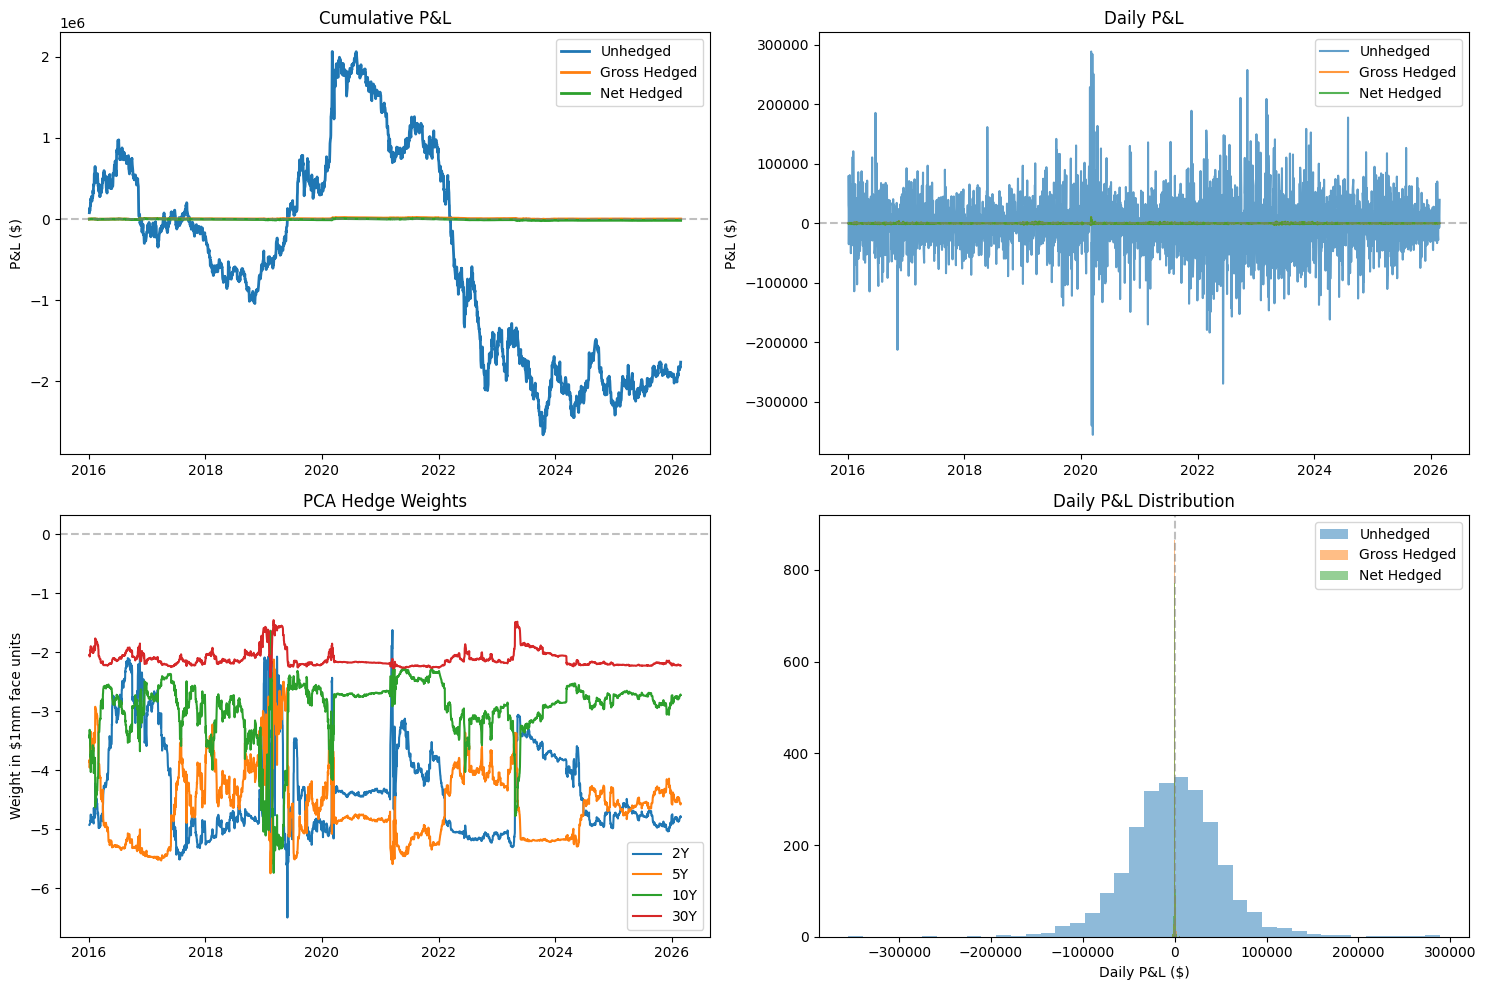

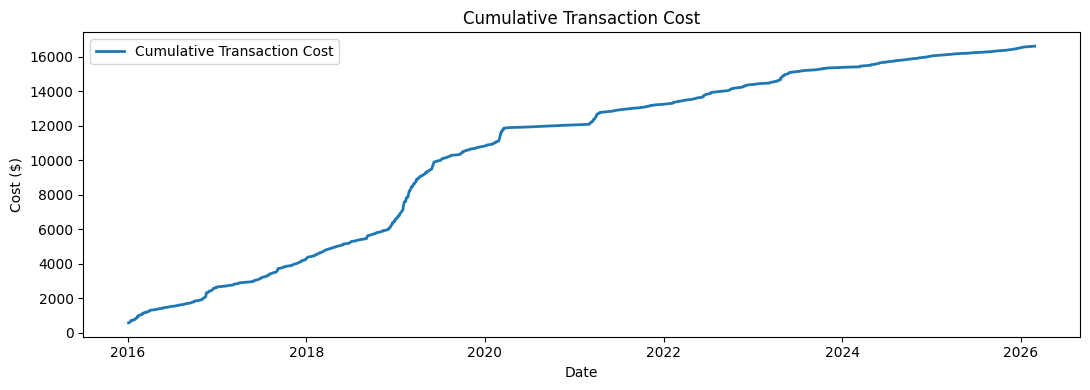

In [363]:
# =========================
# Multi-Day Hedge Backtest Reporting
# Gross vs Net Transaction-Cost-Aware P&L
# =========================

results_df = pd.DataFrame.from_dict(results, orient="index")
results_df.index = pd.to_datetime(results_df.index)
results_df = results_df.sort_index()
results_df.index.name = "date"

# Expand hedge weights
hedge_weights_df = pd.DataFrame(
    results_df["hedge_weights"].to_list(),
    index=results_df.index,
    columns=["h_2y", "h_5y", "h_10y", "h_30y"]
)

results_df = pd.concat(
    [results_df.drop(columns=["hedge_weights"]), hedge_weights_df],
    axis=1
)

# Expand turnover if stored as array
if "turnover" in results_df.columns:
    turnover_df = pd.DataFrame(
        results_df["turnover"].to_list(),
        index=results_df.index,
        columns=["turnover_2y", "turnover_5y", "turnover_10y", "turnover_30y"]
    )

    results_df = pd.concat(
        [results_df.drop(columns=["turnover"]), turnover_df],
        axis=1
    )

# Metrics
results_df["abs_unhedged_pnl"] = results_df["unhedged_pnl"].abs()
results_df["abs_gross_hedged_pnl"] = results_df["hedged_pnl"].abs()
results_df["abs_net_hedged_pnl"] = results_df["net_hedged_pnl"].abs()

results_df["gross_hedge_helped"] = (
    results_df["abs_gross_hedged_pnl"] < results_df["abs_unhedged_pnl"]
)
results_df["net_hedge_helped"] = (
    results_df["abs_net_hedged_pnl"] < results_df["abs_unhedged_pnl"]
)

results_df["gross_abs_pnl_reduction"] = (
    results_df["abs_unhedged_pnl"] - results_df["abs_gross_hedged_pnl"]
)
results_df["net_abs_pnl_reduction"] = (
    results_df["abs_unhedged_pnl"] - results_df["abs_net_hedged_pnl"]
)

results_df["cum_unhedged_pnl"] = results_df["unhedged_pnl"].cumsum()
results_df["cum_gross_hedged_pnl"] = results_df["hedged_pnl"].cumsum()
results_df["cum_net_hedged_pnl"] = results_df["net_hedged_pnl"].cumsum()
results_df["cum_transaction_cost"] = results_df["transaction_cost"].cumsum()

summary = pd.Series({
    "num_days": len(results_df),

    "avg_abs_unhedged_pnl": results_df["abs_unhedged_pnl"].mean(),
    "avg_abs_gross_hedged_pnl": results_df["abs_gross_hedged_pnl"].mean(),
    "avg_abs_net_hedged_pnl": results_df["abs_net_hedged_pnl"].mean(),

    "unhedged_pnl_vol": results_df["unhedged_pnl"].std(),
    "gross_hedged_pnl_vol": results_df["hedged_pnl"].std(),
    "net_hedged_pnl_vol": results_df["net_hedged_pnl"].std(),

    "worst_unhedged_pnl": results_df["unhedged_pnl"].min(),
    "worst_gross_hedged_pnl": results_df["hedged_pnl"].min(),
    "worst_net_hedged_pnl": results_df["net_hedged_pnl"].min(),

    "gross_hit_rate": results_df["gross_hedge_helped"].mean(),
    "net_hit_rate": results_df["net_hedge_helped"].mean(),

    "total_unhedged_pnl": results_df["unhedged_pnl"].sum(),
    "total_gross_hedged_pnl": results_df["hedged_pnl"].sum(),
    "total_net_hedged_pnl": results_df["net_hedged_pnl"].sum(),

    "total_transaction_cost": results_df["transaction_cost"].sum(),
    "avg_daily_transaction_cost": results_df["transaction_cost"].mean(),
})

summary["gross_avg_abs_pnl_reduction_pct"] = (
    1 - summary["avg_abs_gross_hedged_pnl"] / summary["avg_abs_unhedged_pnl"]
)

summary["net_avg_abs_pnl_reduction_pct"] = (
    1 - summary["avg_abs_net_hedged_pnl"] / summary["avg_abs_unhedged_pnl"]
)

summary["gross_pnl_vol_reduction_pct"] = (
    1 - summary["gross_hedged_pnl_vol"] / summary["unhedged_pnl_vol"]
)

summary["net_pnl_vol_reduction_pct"] = (
    1 - summary["net_hedged_pnl_vol"] / summary["unhedged_pnl_vol"]
)

display(summary.to_frame("value"))
display(results_df.head())

print(
    f"Gross hedge reduced average absolute daily P&L by "
    f"{summary['gross_avg_abs_pnl_reduction_pct']:.2%}."
)
print(
    f"Net hedge reduced average absolute daily P&L by "
    f"{summary['net_avg_abs_pnl_reduction_pct']:.2%} after transaction costs."
)
print(
    f"Gross hedge reduced daily P&L volatility by "
    f"{summary['gross_pnl_vol_reduction_pct']:.2%}."
)
print(
    f"Net hedge reduced daily P&L volatility by "
    f"{summary['net_pnl_vol_reduction_pct']:.2%} after transaction costs."
)
print(
    f"Net hedge reduced absolute P&L on "
    f"{summary['net_hit_rate']:.2%} of days."
)
print(
    f"Total transaction cost: "
    f"${summary['total_transaction_cost']:,.2f}."
)

# =========================
# Plots
# =========================

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# Cumulative P&L
ax[0, 0].plot(results_df.index, results_df["cum_unhedged_pnl"], label="Unhedged", linewidth=2)
ax[0, 0].plot(results_df.index, results_df["cum_gross_hedged_pnl"], label="Gross Hedged", linewidth=2)
ax[0, 0].plot(results_df.index, results_df["cum_net_hedged_pnl"], label="Net Hedged", linewidth=2)
ax[0, 0].axhline(0, color="gray", linestyle="--", alpha=0.5)
ax[0, 0].set_title("Cumulative P&L")
ax[0, 0].set_ylabel("P&L ($)")
ax[0, 0].legend()

# Daily P&L
ax[0, 1].plot(results_df.index, results_df["unhedged_pnl"], label="Unhedged", alpha=0.7)
ax[0, 1].plot(results_df.index, results_df["hedged_pnl"], label="Gross Hedged", alpha=0.8)
ax[0, 1].plot(results_df.index, results_df["net_hedged_pnl"], label="Net Hedged", alpha=0.8)
ax[0, 1].axhline(0, color="gray", linestyle="--", alpha=0.5)
ax[0, 1].set_title("Daily P&L")
ax[0, 1].set_ylabel("P&L ($)")
ax[0, 1].legend()

# Hedge weights
ax[1, 0].plot(results_df.index, results_df["h_2y"], label="2Y")
ax[1, 0].plot(results_df.index, results_df["h_5y"], label="5Y")
ax[1, 0].plot(results_df.index, results_df["h_10y"], label="10Y")
ax[1, 0].plot(results_df.index, results_df["h_30y"], label="30Y")
ax[1, 0].axhline(0, color="gray", linestyle="--", alpha=0.5)
ax[1, 0].set_title("PCA Hedge Weights")
ax[1, 0].set_ylabel("Weight in $1mm face units")
ax[1, 0].legend()

# P&L distribution
ax[1, 1].hist(results_df["unhedged_pnl"], bins=40, alpha=0.5, label="Unhedged")
ax[1, 1].hist(results_df["hedged_pnl"], bins=40, alpha=0.5, label="Gross Hedged")
ax[1, 1].hist(results_df["net_hedged_pnl"], bins=40, alpha=0.5, label="Net Hedged")
ax[1, 1].axvline(0, color="gray", linestyle="--", alpha=0.5)
ax[1, 1].set_title("Daily P&L Distribution")
ax[1, 1].set_xlabel("Daily P&L ($)")
ax[1, 1].legend()

plt.tight_layout()
plt.show()

# Optional: transaction cost plot
plt.figure(figsize=(11, 4))
plt.plot(results_df.index, results_df["cum_transaction_cost"], label="Cumulative Transaction Cost", linewidth=2)
plt.title("Cumulative Transaction Cost")
plt.xlabel("Date")
plt.ylabel("Cost ($)")
plt.legend()
plt.tight_layout()
plt.show()

In [347]:
hedge_instruments

,bond,face_value,coupon,maturity,frequency,positions
0,2Y Hedge Note,1000000,0.04,2,2,1
1,5Y Hedge Note,1000000,0.04,5,2,1
2,10Y Hedge Note,1000000,0.04,10,2,1
3,30Y Hedge Bond,1000000,0.04,30,2,1


In [303]:
def make_delta_ladder(portfolio, rates_data, date):
    maturities = rates_data.tenors
    
    delta_ladder = []
    
    for maturity in maturities:
        # Bumping rates for the chosen maturity
        rates_up, rates_down = bump_curve(rates_data, date, maturity)
        
        cs_up = CubicSpline(rates_up.index.astype(float).to_numpy(), rates_up.to_numpy(dtype = float))
        cs_down = CubicSpline(rates_down.index.astype(float).to_numpy(), rates_down.to_numpy(dtype = float))
        
        price_up = portfolio.apply(lambda row: bond_pricer(row["face_value"], row["coupon"],
                                                                        row["maturity"], rates_up, cs_up,
                                                                        row["frequency"]), axis = 1)
        
        price_down = portfolio.apply(lambda row: bond_pricer(row["face_value"], row["coupon"],
                                                                        row["maturity"], rates_down, cs_down,
                                                                        row["frequency"]), axis = 1)
        for i in range(len(portfolio)):
            price_up = bond_pricer(portfolio.loc
        key_rate_dv01 = (price_down - price_up)/2
        signed_key_rate_dv01 = key_rate_dv01*portfolio["positions"]
        total_signed_key_rate_dv01 = signed_key_rate_dv01.sum()
        delta_ladder.append(total_signed_key_rate_dv01)

    return np.array(delta_ladder)

(3,)

array([Timestamp('2016-01-05 00:00:00'), Timestamp('2016-01-06 00:00:00'),
       Timestamp('2016-01-07 00:00:00'), ...,
       Timestamp('2026-02-24 00:00:00'), Timestamp('2026-02-25 00:00:00'),
       Timestamp('2026-02-26 00:00:00')], dtype=object)

In [331]:
abs(d)

array([10, 20, 30])

In [325]:
v@d.T

array([140, 200, 260])